In [6]:
!pip -q install datasets transformers pillow pandas tqdm

In [7]:
import os
import re
import random
import json
from collections import Counter

import torch
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import CLIPProcessor, CLIPModel

In [8]:
# Reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# How many image-caption pairs you want
NUM_PAIRS = 1000

# CLIP model
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

# Output directory
OUTPUT_DIR = "/content/flickr30k_clip_preprocessed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [9]:
from datasets import load_dataset

# This version works (parquet-based, no script)
dataset = load_dataset("lmms-lab/flickr30k", split="test")

print(dataset)
print(dataset[0])

README.md: 0.00B [00:00, ?B/s]

data/test-00000-of-00009.parquet:   0%|          | 0.00/471M [00:00<?, ?B/s]

data/test-00001-of-00009.parquet:   0%|          | 0.00/475M [00:00<?, ?B/s]

data/test-00002-of-00009.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

data/test-00003-of-00009.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

data/test-00006-of-00009.parquet:   0%|          | 0.00/528M [00:00<?, ?B/s]

data/test-00007-of-00009.parquet:   0%|          | 0.00/511M [00:00<?, ?B/s]

data/test-00008-of-00009.parquet:   0%|          | 0.00/477M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/31783 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'caption', 'sentids', 'img_id', 'filename'],
    num_rows: 31783
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500 at 0x7CD5384D1A00>, 'caption': ['Two young guys with shaggy hair look at their hands while hanging out in the yard .', 'Two young  White males are outside near many bushes .', 'Two men in green shirts are standing in a yard .', 'A man in a blue shirt standing in a garden .', 'Two friends enjoy time spent together .'], 'sentids': ['0', '1', '2', '3', '4'], 'img_id': '0', 'filename': '1000092795.jpg'}


In [10]:
pairs = []

for ex in dataset.select(range(1000)):
    caption = ex["caption"]

    # If caption is a list, take the first one
    if isinstance(caption, list):
        caption = caption[0]

    pairs.append({
        "image": ex["image"],
        "caption": caption
    })

print("Total pairs:", len(pairs))
print("Example caption:", pairs[0]["caption"])

Total pairs: 1000
Example caption: Two young guys with shaggy hair look at their hands while hanging out in the yard .


In [11]:
def clean_caption(text):
    text = text.strip()
    text = text.lower()

    # Remove weird whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove URLs if any
    text = re.sub(r"http\S+|www\S+", "", text)

    # Keep letters, numbers, and basic punctuation
    text = re.sub(r"[^a-z0-9\s.,!?\'-]", "", text)

    # Remove extra spaces again
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [12]:
cleaned_pairs = []
seen = set()

for item in pairs:
    caption = clean_caption(item["caption"])

    if len(caption) < 5:
        continue
    if len(caption.split()) < 3:
        continue

    # Deduplicate captions
    if caption in seen:
        continue
    seen.add(caption)

    cleaned_pairs.append({
        "image": item["image"],
        "caption": caption
    })

print("Pairs after cleaning:", len(cleaned_pairs))

Pairs after cleaning: 1000


In [13]:
import random

NUM_PAIRS = 1000

if len(cleaned_pairs) < NUM_PAIRS:
    sampled_pairs = cleaned_pairs
else:
    sampled_pairs = random.sample(cleaned_pairs, NUM_PAIRS)

print("Final sampled pairs:", len(sampled_pairs))

Final sampled pairs: 1000


In [14]:
from transformers import CLIPProcessor

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
print("Loaded processor:", CLIP_MODEL_NAME)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Loaded processor: openai/clip-vit-base-patch32


In [15]:
from tqdm.auto import tqdm
import torch

processed_data = []

for item in tqdm(pairs, desc="Preprocessing with CLIP"):
    image = item["image"].convert("RGB")
    caption = item["caption"]

    encoded = processor(
        text=[caption],
        images=image,
        return_tensors="pt",
        padding="max_length",
        truncation=True
    )

    processed_data.append({
        "caption": caption,
        "pixel_values": encoded["pixel_values"].squeeze(0),
        "input_ids": encoded["input_ids"].squeeze(0),
        "attention_mask": encoded["attention_mask"].squeeze(0)
    })

print("Processed items:", len(processed_data))
print("pixel_values shape:", processed_data[0]["pixel_values"].shape)
print("input_ids shape:", processed_data[0]["input_ids"].shape)

Preprocessing with CLIP:   0%|          | 0/1000 [00:00<?, ?it/s]

Processed items: 1000
pixel_values shape: torch.Size([3, 224, 224])
input_ids shape: torch.Size([77])


# saving processed data

In [16]:
import os

OUTPUT_DIR = "/content/flickr30k_clip_preprocessed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

save_path = os.path.join(OUTPUT_DIR, "flickr30k_clip_1000_pairs.pt")

torch.save(processed_data, save_path)

print("Saved to:", save_path)

Saved to: /content/flickr30k_clip_preprocessed/flickr30k_clip_1000_pairs.pt


In [17]:
import pandas as pd

metadata = pd.DataFrame({
    "index": list(range(len(processed_data))),
    "caption": [x["caption"] for x in processed_data]
})

csv_path = os.path.join(OUTPUT_DIR, "captions.csv")
metadata.to_csv(csv_path, index=False)

print("Saved CSV to:", csv_path)
metadata.head()

Saved CSV to: /content/flickr30k_clip_preprocessed/captions.csv


,index,caption
0,0,Two young guys with shaggy hair look at their ...
1,1,Several men in hard hats are operating a giant...
2,2,A child in a pink dress is climbing up a set o...
3,3,Someone in a blue shirt and hat is standing on...
4,4,Two men one in a gray shirt one in a black s...


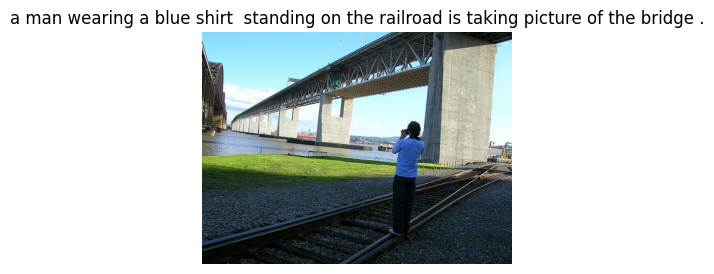

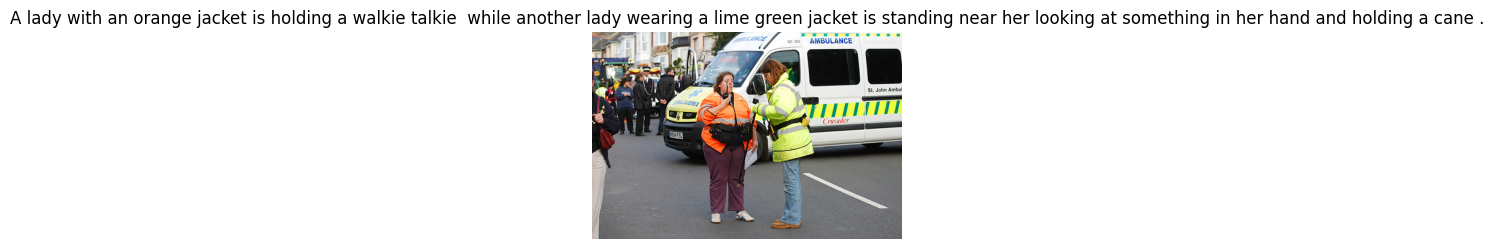

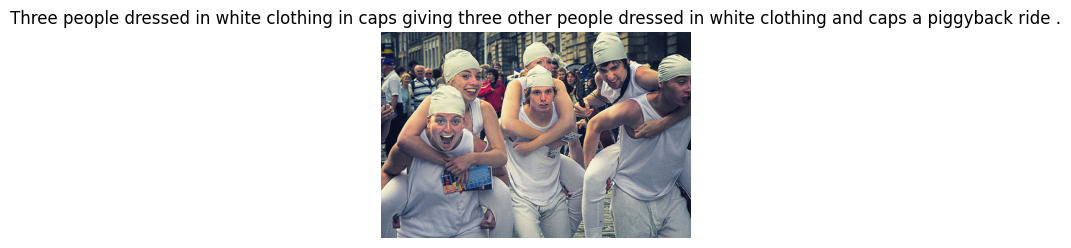

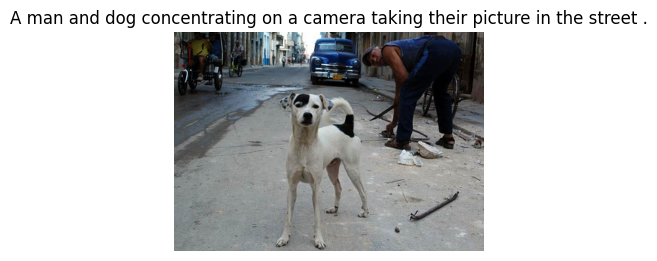

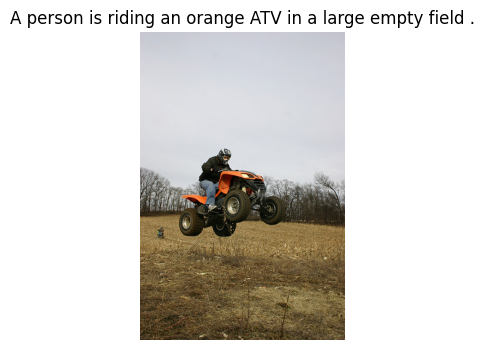

In [18]:
import matplotlib.pyplot as plt
import random

def show_samples(pairs, n=5):
    indices = random.sample(range(len(pairs)), n)

    for i in indices:
        item = pairs[i]
        img = item["image"]
        cap = item["caption"]

        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(cap)
        plt.show()

show_samples(pairs, n=5)